# EDA: HDB resale transactions

**Goal:** understand the raw transactions first, then decide how to turn each sale into features for clustering.
Stage 0 (`../PLAN_HDB.md`, "Stage 0 results") found that HDBSCAN clusters mostly follow single storey bands and
that floor area alone matches flat type. This notebook checks the raw data behind those findings.

**Data** (data.gov.sg, downloaded 14 Sep 2026; no API key needed). Download first, from the project root:
`python -m hdb.datagov`

| File | data.gov.sg dataset | Rows |
|---|---|---|
| `data/raw/resale_2026-09-14.csv` | Resale flat prices based on registration date from Jan-2017 onwards (`d_8b84c4ee58e3cfc0ece0d773c8ca6abc`) | one per resale transaction |
| `data/raw/price_index_2026-09-14.csv` | HDB Resale Price Index (1Q2009 = 100), Quarterly (`d_14f63e595975691e7c24a27ae4c07c79`) | one per quarter |

Kernel: "Python (sc4020-hdb)".

**Terms used in this notebook**

| Term | Meaning |
|---|---|
| sale | One row of the resale file: one flat sold on the open market, dated by the month the resale was registered |
| HDB flat | Public housing built by the Housing & Development Board, sold on a 99-year lease |
| remaining lease | Years and months left on the 99-year lease at the time of sale |
| storey band | The floor of the flat, given only as a range of 3 storeys (e.g. `10 TO 12`) |
| price index | HDB's quarterly resale price index, 100 in 2009-Q1; used to put prices from different quarters on one price level |
| adjusted price | price × (latest index ÷ index of the sale quarter): the price in 2026-Q2 terms |
| tie | Two or more sales with identical feature values, e.g. same floor area, storey band and lease |

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

from hdb.datagov import latest_download
from hdb.features import (
    SCREENING_FEATURES,
    load_price_index,
    load_resale,
    real_prices,
    remaining_lease_years,
    sale_quarter,
    standardize,
    storey_midpoint,
)

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

## 1. Raw data inventory

In [2]:
resale_path, index_path = latest_download("resale"), latest_download("price_index")
raw = pd.read_csv(resale_path)
index_raw = pd.read_csv(index_path)
print(resale_path.name, raw.shape)
print(index_path.name, index_raw.shape)
raw.head(3).T

resale_2026-09-14.csv (240345, 11)
price_index_2026-09-14.csv (146, 2)


,0,1,2
month,2017-01,2017-01,2017-01
town,ANG MO KIO,ANG MO KIO,ANG MO KIO
flat_type,2 ROOM,3 ROOM,3 ROOM
block,406,108,602
street_name,ANG MO KIO AVE 10,ANG MO KIO AVE 4,ANG MO KIO AVE 5
storey_range,10 TO 12,01 TO 03,01 TO 03
floor_area_sqm,44.0,67.0,67.0
flat_model,Improved,New Generation,New Generation
lease_commence_date,1979,1978,1980
remaining_lease,61 years 04 months,60 years 07 months,62 years 05 months


In [3]:
pd.concat([index_raw.head(3), index_raw.tail(3)])

,quarter,index
0,1990-Q1,24.3
1,1990-Q2,24.4
2,1990-Q3,25.0
143,2025-Q4,203.6
144,2026-Q1,203.4
145,2026-Q2,202.8


### Column dictionary

data.gov.sg gives no per-column definitions for the resale file; the dataset notes say floor area "includes
any recess area purchased, space adding item under HDB's upgrading programmes, roof terrace, etc." and that
the file "exclude[s] resale transactions that may not reflect the full market price such as resale between
relatives and resale of part shares". Meanings below describe what the file contains.

| Column | Meaning | Example |
|---|---|---|
| `month` | Month the resale was registered, `YYYY-MM` | `2017-01` |
| `town` | HDB town (planning area used by HDB) | `ANG MO KIO` |
| `flat_type` | Number of rooms, or `EXECUTIVE` / `MULTI-GENERATION` | `2 ROOM` |
| `block`, `street_name` | Address of the block | `406`, `ANG MO KIO AVE 10` |
| `storey_range` | Floor, as a band of 3 storeys | `10 TO 12` |
| `floor_area_sqm` | Approximate floor area in m² (see note above) | `44` |
| `flat_model` | Design of the flat | `Improved` |
| `lease_commence_date` | Year the 99-year lease started | `1979` |
| `remaining_lease` | Lease left at sale, text | `61 years 04 months` |
| `resale_price` | Price in S$ | `232000` |
| `quarter`, `index` (index file) | Quarter and resale price index, 2009-Q1 = 100 | `1990-Q1`, `24.3` |

**Observations**

- The resale file has 240,345 sales and 11 columns; the index file has 146 quarters and 2 columns (1990-Q1 to 2026-Q2).
- The index ends at 202.8 in 2026-Q2, and it stood at 133.9 in 2017-Q1 (section 8).
- Every row is one sale; there is no transaction id, so a duplicate check needs all columns (section 5).

## 2. Types and completeness

In [4]:
def column_overview(frame):
    return pd.DataFrame(
        {
            "dtype": frame.dtypes.astype(str),
            "missing": frame.isna().sum(),
            "missing %": 100 * frame.isna().mean(),
            "unique": frame.nunique(),
            "example": frame.iloc[0],
        }
    )


column_overview(raw)

,dtype,missing,missing %,unique,example
month,str,0,0.0,117,2017-01
town,str,0,0.0,26,ANG MO KIO
flat_type,str,0,0.0,7,2 ROOM
block,str,0,0.0,2780,406
street_name,str,0,0.0,580,ANG MO KIO AVE 10
storey_range,str,0,0.0,17,10 TO 12
floor_area_sqm,float64,0,0.0,197,44.0
flat_model,str,0,0.0,21,Improved
lease_commence_date,int64,0,0.0,58,1979
remaining_lease,str,0,0.0,703,61 years 04 months


In [5]:
column_overview(index_raw)

,dtype,missing,missing %,unique,example
quarter,str,0,0.0,146,1990-Q1
index,float64,0,0.0,132,24.3


**Observations**

- No missing values in either file.
- `floor_area_sqm` and `resale_price` are `float64`; `floor_area_sqm` has 166 non-whole values (section 5). `lease_commence_date` is an integer year.
- `remaining_lease` (703 distinct texts) and `storey_range` (17 bands) are text and must be parsed into numbers.
- 117 months, 26 towns, 7 flat types, 21 flat models, 580 streets.

## 3. Categorical columns

In [6]:
for column in ["flat_type", "storey_range", "town"]:
    counts = raw[column].value_counts()
    print(f"{column}: {len(counts)} values")
    print(counts.to_string(), "\n")

flat_type: 7 values
flat_type
4 ROOM              102144
5 ROOM               58796
3 ROOM               57115
EXECUTIVE            17071
2 ROOM                5042
MULTI-GENERATION        89
1 ROOM                  88 

storey_range: 17 values
storey_range
04 TO 06    55107
07 TO 09    50353
10 TO 12    44880
01 TO 03    42178
13 TO 15    23226
16 TO 18    10888
19 TO 21     4709
22 TO 24     3282
25 TO 27     2052
28 TO 30     1351
31 TO 33      735
34 TO 36      651
37 TO 39      529
40 TO 42      258
43 TO 45       75
46 TO 48       52
49 TO 51       19 

town: 26 values
town
SENGKANG           19443
PUNGGOL            17390
WOODLANDS          17129
TAMPINES           16677
YISHUN             16310
JURONG WEST        15737
BEDOK              12530
HOUGANG            12137
CHOA CHU KANG      10788
BUKIT BATOK        10277
ANG MO KIO          9694
BUKIT MERAH         9148
BUKIT PANJANG       8538
TOA PAYOH           7907
SEMBAWANG           7334
KALLANG/WHAMPOA     7330
PASIR RIS    

In [7]:
models = raw["flat_model"].value_counts()
print(f"flat_model: {len(models)} values")
pd.crosstab(raw["flat_model"], raw["flat_type"]).loc[models.index]

flat_model: 21 values


flat_type,1 ROOM,2 ROOM,3 ROOM,4 ROOM,5 ROOM,EXECUTIVE,MULTI-GENERATION
flat_model,,,,,,,
Model A,0,3142,17058,63492,2997,0,0
Improved,88,636,13746,2579,41605,0,0
New Generation,0,0,18480,10657,0,0,0
Premium Apartment,0,43,1548,13815,9089,1807,0
Simplified,0,0,2480,6694,0,0,0
Apartment,0,0,0,0,0,8561,0
Maisonette,0,0,0,0,0,6542,0
Standard,0,716,3158,84,2413,0,0
DBSS,0,3,528,1584,1694,0,0


**Observations**

- Flat types are very unequal: 4 ROOM 102,144, 5 ROOM 58,796, 3 ROOM 57,115, EXECUTIVE 17,071, 2 ROOM 5,042, and only 89 MULTI-GENERATION and 88 1 ROOM.
- Storey bands are all 3 storeys wide. Sales fall fast with height: 04 TO 06 has 55,107, while 49 TO 51 has 19.
- Towns range from 19,443 sales (SENGKANG) to 582 (BUKIT TIMAH).
- Flat model mostly repeats flat type: `Apartment` (8,561) and `Maisonette` (6,542) are all EXECUTIVE, `Model A2` (2,700) and `Type S1` (389) are all 4 ROOM, `Multi Generation` (89) is all MULTI-GENERATION, and all 88 1 ROOM sales are `Improved`. Only a few models (`Model A`, `Improved`, `Premium Apartment`, `Standard`, `DBSS`) span several flat types.

## 4. Numeric columns

In [8]:
raw.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
floor_area_sqm,240345.0,96.691,24.015,31.0,47.0,63.0,81.0,93.0,112.0,142.0,1.510e+02,3.667e+02
lease_commence_date,240345.0,1996.616,14.392,1966.0,1969.0,1975.0,1985.0,1997.0,2012.0,2018.0,2.020e+03,2.023e+03
resale_price,240345.0,534917.783,192344.858,140000.0,234440.0,280000.0,390000.0,503000.0,640888.0,900000.0,1.100e+06,1.728e+06


**Observations**

- Floor area: median 93 m², 1% to 99% range 47 to 151 m², maximum 366.7 m² (section 12).
- Price: median S$503,000, 1% to 99% range S$234,440 to S$1,100,000, maximum S$1,728,000. The mean (S$534,918) is above the median: prices are right-skewed (section 7).
- Lease start years run from 1966 to 2023 (median 1997).

## 5. Quality checks

Exact duplicate rows, duplicate sales on a looser key, whitespace, impossible values, and whether
`remaining_lease` agrees with `lease_commence_date`. HDB leases are 99 years, so at sale the remaining lease
should be close to 99 − (sale year − lease start year); the months are unknown, so a difference within about
±1 year is expected.

In [9]:
text_columns = raw.select_dtypes(exclude="number").columns
checks = {
    "exact duplicate rows (extra copies)": int(raw.duplicated().sum()),
    "rows in a duplicate group": int(raw.duplicated(keep=False).sum()),
    "text cells with leading/trailing spaces": int(sum((raw[c] != raw[c].str.strip()).sum() for c in text_columns)),
    "floor area <= 0": int((raw["floor_area_sqm"] <= 0).sum()),
    "price <= 0": int((raw["resale_price"] <= 0).sum()),
    "floor area not a whole number": int((raw["floor_area_sqm"] % 1 != 0).sum()),
}
pd.Series(checks, name="count").to_frame()

,count
exact duplicate rows (extra copies),318
rows in a duplicate group,635
text cells with leading/trailing spaces,0
floor area <= 0,0
price <= 0,0
floor area not a whole number,166


In [10]:
duplicates = raw[raw.duplicated(keep=False)]
print("duplicate group sizes:", duplicates.groupby(list(raw.columns)).size().value_counts().to_dict())
print("share by year of duplicate rows:", duplicates["month"].str[:4].value_counts().sort_index().to_dict())
duplicates.sort_values(list(raw.columns)).head(6)

duplicate group sizes: {2: 316, 3: 1}
share by year of duplicate rows: {'2017': 344, '2018': 18, '2019': 36, '2020': 40, '2021': 60, '2022': 36, '2023': 28, '2024': 30, '2025': 25, '2026': 18}


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
224,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0
243,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.0,Improved,1975,57 years,470000.0
304,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0
305,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.0,Improved,1979,61 years 02 months,470000.0
505,2017-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,80 years 09 months,470000.0
510,2017-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.0,Model A,1998,80 years 09 months,470000.0


In [11]:
lease = raw["remaining_lease"].map(remaining_lease_years)
sale_year = raw["month"].str[:4].astype(int)
lease_gap = lease - (99 - (sale_year - raw["lease_commence_date"]))
print("remaining lease minus 99-year rule (years):")
print(lease_gap.describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]).round(2).to_string())
print("\nrows more than 1.5 years off:", int((lease_gap.abs() > 1.5).sum()))
raw.assign(lease_gap=lease_gap.round(2)).loc[lease_gap.abs() > 1.5].sort_values("lease_gap").head(10)

remaining lease minus 99-year rule (years):
count    240345.00
mean          0.04
std           0.40
min         -14.92
0.1%         -0.92
1%           -0.83
50%           0.00
99%           0.92
99.9%         1.00
max           1.17

rows more than 1.5 years off: 1


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,lease_gap
206482,2025-01,JURONG EAST,3 ROOM,37,TEBAN GDNS RD,04 TO 06,67.0,Improved,1981,40 years 01 month,350000.0,-14.92


In [12]:
formats = raw["remaining_lease"].str.replace(r"\d+", "N", regex=True).value_counts()
print("remaining_lease text formats:", formats.to_dict())
print("formats by year:")
pd.crosstab(raw["month"].str[:4], raw["remaining_lease"].str.contains("month"))

remaining_lease text formats: {'N years N months': 201178, 'N years': 19720, 'N years N month': 19447}
formats by year:


remaining_lease,False,True
month,,
2017,1688,18821
2018,1870,19691
2019,1497,20689
2020,1973,21360
2021,2486,26601
2022,2246,24474
2023,2108,23646
2024,2313,25519
2025,2029,23056


**Observations**

- 318 extra copies of identical rows (635 rows in 316 pairs and one triple). 344 of the 635 are from 2017. The file has no unit number, and a storey band holds 3 floors, so two identical rows can be two different flats in the same block and band sold in the same month at the same price. They cannot be told apart from true duplicates.
- No stray whitespace, no zero or negative prices or floor areas.
- `remaining_lease` agrees with the 99-year rule: median difference 0.00 years, 99.9% within 1.00 year. One sale is 14.92 years off: 37 TEBAN GDNS RD, lease start 1981, sold in 2025-01 with "40 years 01 month" left (the rule gives 55). It is the only such row.
- `remaining_lease` has three text formats: "N years N months" (201,178), "N years N month" (19,447) and "N years" (19,720). Whole-year values appear in every year (1,497 to 2,486 per year), so they are leases with 0 months left, not an older format. `remaining_lease_years` in `hdb/features.py` handles all three.

**Decision:** keep the 318 identical rows (they may be different flats; 0.13% of sales). Keep the Teban Gardens row but list it; one row cannot change any cluster.

## 6. Absent vs missing

A missing row here means no sale was registered, not an unknown value: the file lists transactions only.
The one real gap is the price index, which is published after each quarter ends.

In [13]:
index = load_price_index(index_path)
sale_quarters = raw["month"].map(sale_quarter)
no_index = ~sale_quarters.isin(index.index)
print("latest index quarter:", index.index[-1])
print("sales without an index value:", int(no_index.sum()), f"({no_index.mean():.1%})")
print("their months:", raw.loc[no_index, "month"].value_counts().sort_index().to_dict())

per_month = raw.groupby(["month", "town"]).size().unstack(fill_value=0)
print("\nmonths:", len(per_month), "| town-months with no sale:", int((per_month == 0).sum().sum()))
print("towns with the most months without a sale:", (per_month == 0).sum().sort_values(ascending=False).head(3).to_dict())

latest index quarter: 2026-Q2
sales without an index value: 6051 (2.5%)
their months: {'2026-07': 2649, '2026-08': 2521, '2026-09': 881}

months: 117 | town-months with no sale: 3
towns with the most months without a sale: {'BUKIT TIMAH': 2, 'CENTRAL AREA': 1, 'ANG MO KIO': 0}


**Observations**

- 6,051 sales (2.5%) have no index value: 2,649 in 2026-07, 2,521 in 2026-08 and 881 in 2026-09 (a partial month). The latest index quarter is 2026-Q2.
- Only 3 of 3,042 town-months have no sale (BUKIT TIMAH 2, CENTRAL AREA 1): an absent month means no registered resale, not a missing record.

**Decision:** drop the 6,051 sales without an index value, with a warning (already done by `screening_features`). Carrying the 2026-Q2 index forward would guess a price level; dropping loses 2.5% of sales, all from the last 3 months.

## 7. Raw visualisation

count     117.0
mean     2054.0
std       433.0
min       363.0
25%      1884.0
50%      2114.0
75%      2333.0
max      3036.0
lowest months: {'2020-05': 363, '2020-04': 424, '2026-09': 881}


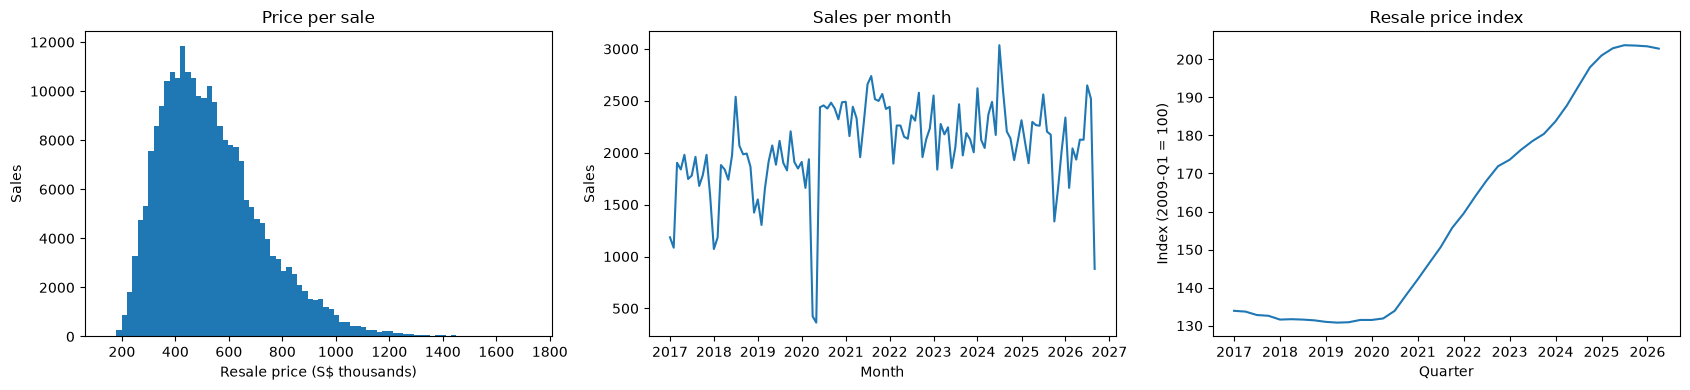

In [14]:
monthly = raw.groupby("month").agg(sales=("resale_price", "size"), median_price=("resale_price", "median"))
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(raw["resale_price"] / 1000, bins=80)
axes[0].set(xlabel="Resale price (S$ thousands)", ylabel="Sales", title="Price per sale")
axes[1].plot(pd.to_datetime(monthly.index), monthly["sales"])
axes[1].set(xlabel="Month", ylabel="Sales", title="Sales per month")
index_since_2017 = index[index.index >= "2017-Q1"]
axes[2].plot(pd.PeriodIndex(index_since_2017.index, freq="Q").to_timestamp(), index_since_2017.to_numpy())
axes[2].set(xlabel="Quarter", ylabel="Index (2009-Q1 = 100)", title="Resale price index")
fig.tight_layout()
print(monthly["sales"].describe().round(0).to_string())
print("lowest months:", monthly["sales"].nsmallest(3).to_dict())

**Observations**

- Prices are right-skewed with a peak around S$400,000 to S$450,000 and a long tail above S$1,000,000.
- Sales per month: median 2,114, range 363 to 3,036. The two lowest months are 2020-05 (363) and 2020-04 (424), during Singapore's COVID-19 circuit breaker; 2026-09 (881) is a partial month.
- The index is flat from 2017 to 2020 (about 131 to 134) and then rises to about 203 by 2025, where it levels off.

**Decision:** adjust prices with the index. Nominal prices from 2017 and 2025 are on different price levels (section 13 shows the effect).

## 8. From raw rows to features

Two contrasting sales (an old small flat early in the period, a new large flat late in the period), before and
after each step: parse remaining lease to years, storey band to its midpoint, adjust price with the index, then
standardize (using the mean and standard deviation of all sales with an index value).

In [15]:
examples = raw.loc[~no_index]
small_old = examples[(examples["flat_type"] == "3 ROOM") & (examples["month"] == "2017-01")].iloc[0]
large_new = examples[
    (examples["flat_type"] == "5 ROOM") & (examples["month"] == "2026-06") & examples["remaining_lease"].str.startswith("9")
].iloc[-1]
pair = pd.DataFrame([small_old, large_new])
pair[["month", "flat_type", "storey_range", "floor_area_sqm", "remaining_lease", "resale_price"]]

,month,flat_type,storey_range,floor_area_sqm,remaining_lease,resale_price
1,2017-01,3 ROOM,01 TO 03,67.0,60 years 07 months,250000.0
240261,2026-06,5 ROOM,10 TO 12,113.0,90 years 02 months,765000.0


In [16]:
features = pd.DataFrame(
    {
        "floor_area_sqm": raw["floor_area_sqm"],
        "remaining_lease_years": lease,
        "storey_mid": raw["storey_range"].map(storey_midpoint),
        "real_price": real_prices(raw, index),
    }
)[~no_index]
steps = pd.DataFrame(
    {
        "sale quarter": pair["month"].map(sale_quarter),
        "index at sale": pair["month"].map(sale_quarter).map(index),
        "remaining_lease_years": pair["remaining_lease"].map(remaining_lease_years),
        "storey_mid": pair["storey_range"].map(storey_midpoint),
        "nominal price": pair["resale_price"],
        "real_price": real_prices(pair, index),
    }
)
scaled = pd.DataFrame(standardize(features), columns=SCREENING_FEATURES, index=features.index).loc[pair.index]
display(steps)
display(scaled.add_suffix(" (standardized)"))

,sale quarter,index at sale,remaining_lease_years,storey_mid,nominal price,real_price
1,2017-Q1,133.9,60.583,2.0,250000.0,378640.777
240261,2026-Q2,202.8,90.167,11.0,765000.0,765000.000


,floor_area_sqm (standardized),remaining_lease_years (standardized),storey_mid (standardized),real_price (standardized)
1,-1.236,-0.948,-1.139,-1.332
240261,0.679,1.121,0.372,0.435


**Observations**

- Old small flat: 3 ROOM in ANG MO KIO, sold 2017-01, 67 m², storey 01 TO 03, 60 years 07 months left, S$250,000. Lease becomes 60.583 years, storey 2.0. The 2017-Q1 index is 133.9, so the adjusted price is 250,000 × 202.8 / 133.9 = S$378,641.
- Newer large flat: 5 ROOM in YISHUN, sold 2026-06, 113 m², storey 10 TO 12, 90 years 02 months left, S$765,000. Lease 90.167 years, storey 11.0. Its quarter (2026-Q2) is the reference, so the adjusted price stays S$765,000.
- After standardizing, the two sales differ on all four features: floor area -1.236 vs 0.679, lease -0.948 vs 1.121, storey -1.139 vs 0.372, price -1.332 vs 0.435. No feature exceeds about 2 units of difference, so no feature dominates.

## 9. Scale: would one feature dominate distances?

Euclidean distance adds squared differences per feature, so a feature's share of the total variance is its
share of the average squared distance between two random sales.

In [17]:
variance = features.var()
pd.DataFrame(
    {
        "std (raw units)": features.std(),
        "share of squared distance, raw": variance / variance.sum(),
        "share, standardized": 1 / features.shape[1],
    }
)

,std (raw units),"share of squared distance, raw","share, standardized"
floor_area_sqm,24.017,1.206e-08,0.25
remaining_lease_years,14.299,4.274e-09,0.25
storey_mid,5.954,7.410e-10,0.25
real_price,218714.774,1.000e+00,0.25


**Observations**

- In raw units, `real_price` has a standard deviation of S$218,715, against 24.0 m² for floor area, 14.3 years for lease and 6.0 storeys.
- Price's share of the squared distance between sales is 1.000; the other three together are under 0.00000002. On raw features, distance is price alone.

**Decision:** standardize all features (mean 0, standard deviation 1) by default, giving each 25% of the variance. Keep raw features as a Stage 4 ablation (Stage 0: raw K-means cut sales into 6 price bands that do not overlap, `results/screening_roles.csv`).

## 10. Feature coverage and discrete values

No feature is constant, but three of the four take few distinct values. Many sales then share the exact same
point, and a density method sees each repeated point as a dense spot (Stage 0).

In [18]:
coverage = pd.DataFrame(
    {
        "distinct values": features.nunique(),
        "most common value": features.mode().iloc[0],
        "share at most common value": [features[c].value_counts(normalize=True).iloc[0] for c in features],
    }
)
display(coverage)

no_price = ["floor_area_sqm", "remaining_lease_years", "storey_mid"]
tied = features.duplicated(subset=no_price, keep=False)
group_sizes = features.groupby(no_price).size()
print(f"sales sharing floor area, lease and storey with another sale: {tied.mean():.1%}")
print(f"distinct (floor area, lease, storey) points: {len(group_sizes)} for {len(features)} sales")
print("largest tie groups:", group_sizes.nlargest(3).to_dict())

,distinct values,most common value,share at most common value
floor_area_sqm,192,93.000,8.511e-02
remaining_lease_years,697,94.833,8.208e-03
storey_mid,17,5.000,2.293e-01
real_price,32964,676000.000,9.048e-04


sales sharing floor area, lease and storey with another sale: 77.7%
distinct (floor area, lease, storey) points: 91510 for 234294 sales
largest tie groups: {(93.0, 94.75, 5.0): 133, (93.0, 94.91666666666667, 8.0): 133, (93.0, 94.75, 8.0): 128}


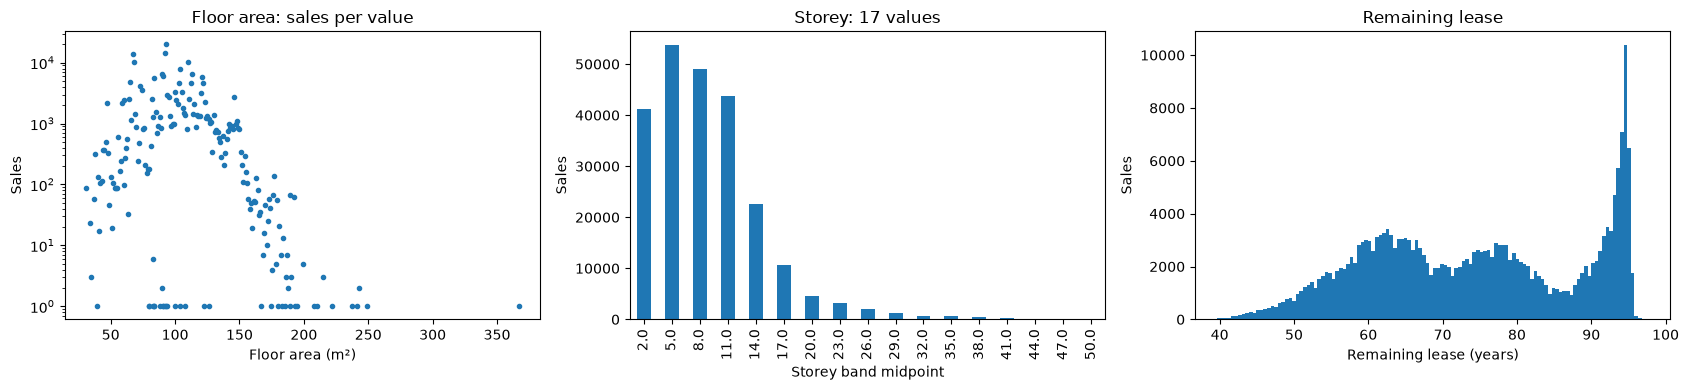

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
features["floor_area_sqm"].value_counts().sort_index().plot(ax=axes[0], style=".")
axes[0].set(xlabel="Floor area (m²)", ylabel="Sales", title="Floor area: sales per value", yscale="log")
features["storey_mid"].value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set(xlabel="Storey band midpoint", ylabel="Sales", title="Storey: 17 values")
axes[2].hist(features["remaining_lease_years"], bins=120)
axes[2].set(xlabel="Remaining lease (years)", ylabel="Sales", title="Remaining lease")
fig.tight_layout()

**Observations**

- No constant features. But three features take few distinct values: storey has 17 (22.9% of sales at 5.0), floor area 192 (8.5% at 93 m²), remaining lease 697 month values.
- 77.7% of sales share their exact floor area, lease and storey with at least one other sale: 234,294 sales sit on 91,510 distinct points. The largest ties hold 133 sales each (93 m², about 94.8 years left, storey 5 or 8).
- The floor area plot shows sales per value from 1 to over 20,000 (log scale), so a small set of sizes holds most sales; the storey plot shows 17 bars, and the lease histogram a sharp peak at about 94 to 95 years. That peak matches flats resold soon after a 5-year minimum occupation period (99 − 5 = 94); this notebook does not check that explanation.

**Decision:** keep storey as the band midpoint for K-means. For DBSCAN and HDBSCAN, ties create artificial dense points (Stage 0: 14 of 17 HDBSCAN clusters were single storey bands). Stage 2 adds an option to spread each value uniformly within its band (storey ±1.5, floor area ±0.5 m², lease ±0.5 month), and Stage 3 runs density methods on both, reporting the difference as a finding.

## 11. Typical patterns and spread by flat type

In [20]:
by_type = features.assign(flat_type=raw.loc[features.index, "flat_type"]).groupby("flat_type")
summary = by_type.agg(["median", lambda v: v.quantile(0.75) - v.quantile(0.25)])
summary.columns = [f"{feature} {'median' if stat == 'median' else 'IQR'}" for feature, stat in summary.columns]
summary.insert(0, "sales", by_type.size())
summary.sort_values("floor_area_sqm median")

,sales,floor_area_sqm median,floor_area_sqm IQR,remaining_lease_years median,remaining_lease_years IQR,storey_mid median,storey_mid IQR,real_price median,real_price IQR
flat_type,,,,,,,,,
1 ROOM,87,31.0,0.00,53.000,4.958,5.0,9.0,2.742e+05,25885.381
2 ROOM,4876,47.0,2.00,91.833,32.250,8.0,6.0,3.636e+05,50448.918
3 ROOM,55797,67.0,5.00,60.250,12.583,8.0,6.0,4.480e+05,103117.719
4 ROOM,99470,93.0,10.00,78.000,25.917,8.0,6.0,6.283e+05,164142.765
5 ROOM,57302,117.0,10.00,77.417,15.667,8.0,9.0,7.471e+05,210862.107
EXECUTIVE,16676,146.0,7.00,71.417,10.000,8.0,6.0,9.240e+05,197552.904
MULTI-GENERATION,86,164.0,6.75,65.708,3.167,8.0,6.0,1.157e+06,181342.875


,min,p01,p99,max
flat_type,,,,
1 ROOM,31.0,31.0,31.0,31.0
2 ROOM,34.0,37.0,54.0,67.0
3 ROOM,51.0,56.0,88.0,366.7
4 ROOM,70.0,82.0,112.0,176.0
5 ROOM,99.0,107.0,139.0,167.0
EXECUTIVE,124.0,125.0,184.0,243.0
MULTI-GENERATION,132.0,132.0,179.0,179.0


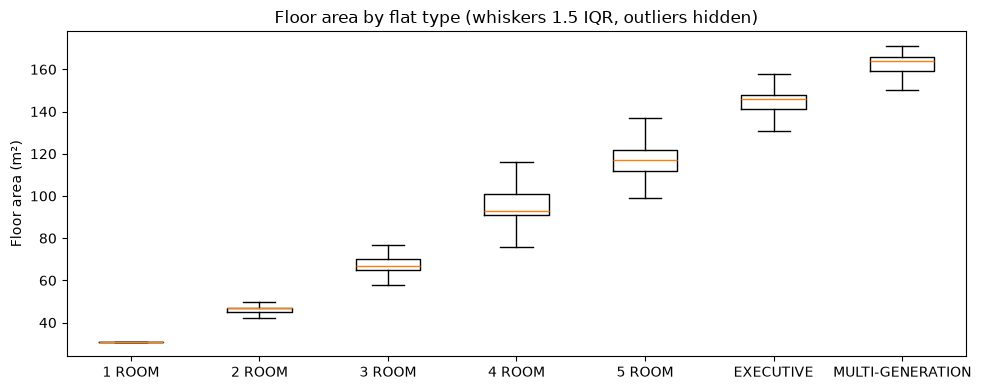

In [21]:
areas = raw.groupby("flat_type")["floor_area_sqm"]
order = areas.median().sort_values().index
ranges = pd.DataFrame({"min": areas.min(), "p01": areas.quantile(0.01), "p99": areas.quantile(0.99), "max": areas.max()}).loc[order]
display(ranges)

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([raw.loc[raw["flat_type"] == t, "floor_area_sqm"] for t in order], showfliers=False)
ax.set_xticks(range(1, len(order) + 1), order)
ax.set(ylabel="Floor area (m²)", title="Floor area by flat type (whiskers 1.5 IQR, outliers hidden)")
fig.tight_layout()

**Observations**

- Floor area separates flat types almost completely. Medians: 1 ROOM 31, 2 ROOM 47, 3 ROOM 67, 4 ROOM 93, 5 ROOM 117, EXECUTIVE 146, MULTI-GENERATION 164 m²; IQRs are only 0 to 10 m². In the box plot, the whiskers of neighbouring types barely overlap.
- Remaining lease varies much more within types: 2 ROOM IQR 32.3 years, 4 ROOM 25.9 years.
- Storey medians are 8.0 for every type except 1 ROOM (5.0).
- Adjusted price rises with type: median S$274,000 (1 ROOM) to S$1,157,000 (MULTI-GENERATION), with IQRs of S$26,000 to S$211,000 that overlap between neighbouring types.

**Decision:** flat type is a size label. ARI against flat type is reported next to a floor-area-only baseline (Stage 0: 0.601 for floor area alone vs 0.237 for all four features).

## 12. Outliers and extremes

In [22]:
with_features = raw.loc[features.index].assign(real_price=features["real_price"], price_per_sqm=raw["resale_price"] / raw["floor_area_sqm"])
columns = ["month", "town", "flat_type", "block", "street_name", "storey_range", "floor_area_sqm", "flat_model", "remaining_lease", "resale_price", "price_per_sqm"]
print("largest floor areas:")
display(with_features.nlargest(5, "floor_area_sqm")[columns])
print("highest and lowest price per m²:")
display(pd.concat([with_features.nlargest(3, "price_per_sqm"), with_features.nsmallest(3, "price_per_sqm")])[columns])

largest floor areas:


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,remaining_lease,resale_price,price_per_sqm
182823,2024-07,KALLANG/WHAMPOA,3 ROOM,53,JLN MA'MOR,01 TO 03,366.7,Terrace,47 years,1.568e+06,4275.975
19693,2017-12,KALLANG/WHAMPOA,3 ROOM,65,JLN MA'MOR,01 TO 03,249.0,Terrace,53 years 07 months,1.054e+06,4232.482
92512,2021-03,BISHAN,EXECUTIVE,446,BRIGHT HILL DR,07 TO 09,243.0,Maisonette,68 years 01 month,1.093e+06,4497.481
94959,2021-04,BISHAN,EXECUTIVE,454,SIN MING AVE,10 TO 12,243.0,Maisonette,67 years 08 months,1.001e+06,4119.342
107851,2021-09,KALLANG/WHAMPOA,3 ROOM,46,JLN BAHAGIA,01 TO 03,241.0,Terrace,49 years 10 months,1.235e+06,5124.481


highest and lowest price per m²:


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,remaining_lease,resale_price,price_per_sqm
202725,2025-03,CENTRAL AREA,4 ROOM,1C,CANTONMENT RD,49 TO 51,94.0,Type S1,85 years 02 months,1.518e+06,16148.936
226387,2026-05,CENTRAL AREA,4 ROOM,1C,CANTONMENT RD,40 TO 42,96.0,Type S1,83 years 08 months,1.550e+06,16145.833
202752,2025-09,CENTRAL AREA,4 ROOM,1E,CANTONMENT RD,46 TO 48,93.0,Type S1,84 years 04 months,1.490e+06,16021.505
67560,2020-02,TOA PAYOH,3 ROOM,26,TOA PAYOH EAST,10 TO 12,67.0,Improved,49 years 11 months,1.400e+05,2089.552
50187,2019-05,TOA PAYOH,3 ROOM,38,LOR 5 TOA PAYOH,01 TO 03,77.0,Improved,49 years 08 months,1.700e+05,2207.792
163898,2023-08,TAMPINES,3 ROOM,522A,TAMPINES CTRL 7,07 TO 09,67.0,Model A,91 years 03 months,1.500e+05,2238.806


In [23]:
area_z = by_type["floor_area_sqm"].transform(lambda v: (v - v.median()) / (v.quantile(0.75) - v.quantile(0.25)))
far = with_features.assign(area_iqrs_from_type_median=area_z.round(1)).loc[area_z.abs() > 5]
print("sales whose floor area is more than 5 IQRs from their flat type's median:", len(far))
far["flat_model"].value_counts().head(8)

sales whose floor area is more than 5 IQRs from their flat type's median: 337


flat_model
Apartment            149
Terrace               67
Standard              37
New Generation        32
Maisonette            22
Model A                8
Premium Apartment      7
Improved               6
Name: count, dtype: int64

**Observations**

- The largest flats are 3 ROOM `Terrace` flats in JLN MA'MOR and JLN BAHAGIA (Kallang/Whampoa): 366.7, 249 and 241 m². `Terrace` is a flat model of 117 3 ROOM and 7 4 ROOM sales, so these are real low-rise flats labelled 3 ROOM, not typing errors in floor area.
- The highest prices per m² are 4 ROOM `Type S1` flats at CANTONMENT RD on storeys 40 to 51 (about S$16,000 per m²). The lowest are old 3 ROOM flats with about 49 years left, in TOA PAYOH (S$2,090 per m²), and one TAMPINES 3 ROOM with 91 years left at S$150,000 (S$2,239 per m²).
- 337 sales have a floor area more than 5 IQRs from their flat type's median, mostly `Apartment` (149), `Terrace` (67) and `Standard` (37).

**Decision:** keep all outliers: the extreme rows are identifiable flat models, not errors. List them in cluster interpretation if they form their own cluster or noise. The TAMPINES sale at S$150,000 is listed but kept; the file excludes non-market sales, and one row cannot be checked further.

## 13. Stability over time

Each sale is a separate entity, so there is no per-entity repeat to test. The equivalent check is whether the
feature distributions stay the same across years: if they drift, clusters could follow the year of sale.

In [24]:
yearly = features.assign(year=raw.loc[features.index, "month"].str[:4]).groupby("year")
stability = yearly.median()
stability.insert(0, "sales", yearly.size())
stability["nominal price median"] = raw.loc[features.index].groupby(raw["month"].str[:4])["resale_price"].median()
stability

,sales,floor_area_sqm,remaining_lease_years,storey_mid,real_price,nominal price median
year,,,,,,
2017,20509,96.0,74.667,8.0,626114.458,410000.0
2018,21561,97.0,74.417,8.0,628741.641,408000.0
2019,22186,94.0,74.208,8.0,620183.486,400000.0
2020,23333,93.0,75.417,8.0,643689.320,425000.0
2021,29087,93.0,75.583,8.0,657764.933,483000.0
2022,26720,93.0,74.167,8.0,640607.330,525000.0
2023,25754,93.0,73.667,8.0,629534.368,550000.0
2024,27832,93.0,72.917,8.0,630227.388,590000.0
2025,25085,93.0,71.917,8.0,627216.495,628000.0


In [25]:
type_share = pd.crosstab(raw["month"].str[:4], raw["flat_type"], normalize="index")
type_share.round(3)

flat_type,1 ROOM,2 ROOM,3 ROOM,4 ROOM,5 ROOM,EXECUTIVE,MULTI-GENERATION
month,,,,,,,
2017,0.0,0.011,0.246,0.420,0.244,0.079,0.000
2018,0.0,0.013,0.237,0.407,0.254,0.087,0.001
2019,0.0,0.019,0.244,0.416,0.245,0.075,0.001
2020,0.0,0.018,0.231,0.413,0.256,0.081,0.000
2021,0.0,0.013,0.215,0.424,0.268,0.078,0.001
2022,0.0,0.017,0.237,0.423,0.251,0.071,0.000
2023,0.0,0.027,0.247,0.441,0.227,0.058,0.000
2024,0.0,0.029,0.244,0.431,0.232,0.063,0.000
2025,0.0,0.033,0.245,0.432,0.230,0.059,0.000


**Observations**

- Median features are stable across years: floor area 93 to 97 m², storey 8.0 every year, remaining lease 71.3 to 75.6 years (falling from 75.6 in 2021 to 71.3 in 2026).
- Median nominal price rises from S$410,000 (2017) to S$630,000 (2026). Median adjusted price stays between S$620,000 and S$658,000.
- The flat type mix is also stable: 4 ROOM 40.7% to 44.1% of sales per year, 3 ROOM 21.5% to 24.7%; 2 ROOM rises from 1.1% to 3.3%.

**Decision:** sample Stage 3 data at random (seed 0) instead of stratifying by year: every year has 20,509 to 29,087 sales (12,227 in 2026 after dropping Q3) and the same feature medians. Index adjustment removes the time trend in price; Stage 0 found K-means clusters did not follow sale year either way (ARI 0.006 nominal, 0.001 adjusted), so the nominal-price ablation is dropped from the plan.

## 14. Thresholds: small classes

Flat types and flat models with few sales cannot form clusters of their own at the `min_cluster_size` values
used here, and matter for ARI against flat type. The table shows what each minimum class size keeps.

In [26]:
def class_threshold_table(labels, minimums):
    counts = labels.value_counts()
    return pd.DataFrame(
        [
            {
                "min sales per class": m,
                "classes kept": int((counts >= m).sum()),
                "classes dropped": int((counts < m).sum()),
                "sales dropped": int(counts[counts < m].sum()),
                "sales dropped %": 100 * counts[counts < m].sum() / counts.sum(),
            }
            for m in minimums
        ]
    )


print("flat_type")
display(class_threshold_table(raw["flat_type"], [1, 100, 1000, 10000]))
print("flat_model")
display(class_threshold_table(raw["flat_model"], [1, 100, 1000, 10000]))

flat_type


,min sales per class,classes kept,classes dropped,sales dropped,sales dropped %
0,1,7,0,0,0.000
1,100,5,2,177,0.074
2,1000,5,2,177,0.074
3,10000,4,3,5219,2.171


flat_model


,min sales per class,classes kept,classes dropped,sales dropped,sales dropped %
0,1,21,0,0,0.000
1,100,17,4,226,0.094
2,1000,10,11,2406,1.001
3,10000,4,17,39563,16.461


**Observations**

- Flat type: requiring at least 100 sales per class drops 1 ROOM and MULTI-GENERATION (177 sales, 0.07%). Requiring 10,000 would also drop 2 ROOM (5,219 sales, 2.2%).
- Flat model: at least 1,000 sales keeps 10 of 21 models and drops 2,406 sales (1.0%).

**Decision:** keep all 7 flat types in the data and in ARI; 0.07% of sales cannot move ARI. Flat model is not used as a label or feature (it repeats flat type, section 3); it is used only to describe clusters.

## 15. Dimensionality and correlation

Correlation between the candidate features (including `lease_commence_date` and price per m², which the plan
listed as options), and PCA on the four standardized features.

In [27]:
candidates = features.assign(
    lease_commence_date=raw.loc[features.index, "lease_commence_date"],
    price_per_sqm=features["real_price"] / features["floor_area_sqm"],
)
display(candidates.corr().round(2))

pca = PCA().fit(standardize(features))
explained = pd.DataFrame(
    {"explained": pca.explained_variance_ratio_, "cumulative": pca.explained_variance_ratio_.cumsum()},
    index=[f"PC{i + 1}" for i in range(len(SCREENING_FEATURES))],
)
display(explained)
pd.DataFrame(pca.components_, columns=SCREENING_FEATURES, index=explained.index).round(2)

,floor_area_sqm,remaining_lease_years,storey_mid,real_price,lease_commence_date,price_per_sqm
floor_area_sqm,1.00,0.10,-0.01,0.65,0.09,-0.14
remaining_lease_years,0.10,1.00,0.27,0.36,0.98,0.40
storey_mid,-0.01,0.27,1.00,0.37,0.28,0.51
real_price,0.65,0.36,0.37,1.00,0.35,0.65
lease_commence_date,0.09,0.98,0.28,0.35,1.00,0.40
price_per_sqm,-0.14,0.40,0.51,0.65,0.40,1.00


,explained,cumulative
PC1,0.483,0.483
PC2,0.277,0.760
PC3,0.181,0.942
PC4,0.058,1.000


,floor_area_sqm,remaining_lease_years,storey_mid,real_price
PC1,0.50,0.42,0.38,0.66
PC2,-0.63,0.44,0.63,-0.16
PC3,-0.03,0.78,-0.61,-0.13
PC4,-0.60,-0.15,-0.31,0.72


**Observations**

- `lease_commence_date` correlates 0.98 with remaining lease: it adds nothing, so it is not a feature.
- Price per m² correlates 0.65 with adjusted price and 0.51 with storey, and -0.14 with floor area. It is a ratio of two features already present.
- Adjusted price correlates 0.65 with floor area; storey and lease correlate 0.27.
- PCA on the 4 standardized features: PC1 48.3%, PC1 to PC2 76.0%, PC1 to PC3 94.2%. PC1 loads on all four (price 0.66, area 0.50); PC2 contrasts floor area (-0.63) with storey (0.63) and lease (0.44).

**Decision:** use the 4 features (floor area, remaining lease, storey midpoint, adjusted price) without PCA; 3 components would still be needed for 90%. Price per m² is a Stage 4 feature-set ablation, not a default feature.

## 16. Spatial sanity

The file has no coordinates: location is only `town`, `block` and `street_name`. This section checks what
`town` can offer as a label.

In [28]:
addresses = raw[["block", "street_name"]].drop_duplicates()
print("towns:", raw["town"].nunique(), "| distinct block addresses:", len(addresses), "| streets:", raw["street_name"].nunique())
town_profile = features.assign(town=raw.loc[features.index, "town"]).groupby("town").median()
print("spread of town medians (max / min):")
(town_profile.max() / town_profile.min()).round(2)

towns: 26 | distinct block addresses: 9745 | streets: 580
spread of town medians (max / min):


floor_area_sqm           1.49
remaining_lease_years    1.74
storey_mid               2.80
real_price               1.95
dtype: float64

In [29]:
share_by_town = pd.crosstab(raw["town"], raw["flat_type"], normalize="index")
print("town sales and the share of 4 ROOM:")
raw["town"].value_counts().to_frame("sales").join(share_by_town["4 ROOM"].rename("4 ROOM share")).round(3)

town sales and the share of 4 ROOM:


,sales,4 ROOM share
town,,
SENGKANG,19443,0.499
PUNGGOL,17390,0.528
WOODLANDS,17129,0.453
TAMPINES,16677,0.415
YISHUN,16310,0.487
JURONG WEST,15737,0.375
BEDOK,12530,0.349
HOUGANG,12137,0.453
CHOA CHU KANG,10788,0.486


**Observations**

- No coordinates: 26 towns, 580 streets, 9,745 distinct block addresses.
- Town medians differ: storey medians differ by 2.80x between towns, adjusted price by 1.95x, remaining lease 1.74x, floor area 1.49x.
- Flat mix per town varies: the 4 ROOM share runs from 24.4% (MARINE PARADE) to 52.8% (PUNGGOL).

**Decision:** town is not a label for clustering (Stage 0: ARI 0.049), and blocks are not geocoded. Geocoding 9,745 addresses would add a location feature, which changes the question; town medians are used only to describe clusters.

## 17. Summary: issues, evidence and decisions

| Issue | Evidence | Decision |
|---|---|---|
| Prices on different price levels | Median nominal price S$410,000 (2017) to S$630,000 (2026); adjusted S$620,000 to S$658,000 (sections 7, 13) | Adjust price with the index to 2026-Q2 (`real_prices`) |
| Sales without an index value | 6,051 sales (2.5%), 2026-07 to 2026-09 (section 6) | Drop with a warning (`screening_features`) |
| Remaining lease is text | 3 formats, including 19,720 whole-year values (section 5) | Parse to years (`remaining_lease_years`) |
| Storey is a 3-storey band | 17 values, 22.9% at one value (section 10) | Band midpoint (`storey_midpoint`) |
| Ties create artificial dense points | 77.7% of sales share floor area, lease and storey with another sale; Stage 0: 14 of 17 HDBSCAN clusters were single storey bands (section 10) | Stage 2: optional jitter within each value's band; Stage 3 runs density methods with and without it |
| Price dominates raw distances | Price share of squared distance 1.000 (section 9) | Standardize by default; raw features as a Stage 4 ablation |
| Flat type is defined by size | Floor area medians 31 to 164 m², IQRs 0 to 10 m² (section 11) | Report ARI vs flat type next to a floor-area-only baseline |
| Tiny flat types | 1 ROOM 88, MULTI-GENERATION 89 sales (sections 3, 14) | Keep all 7 types |
| Flat model repeats flat type | e.g. `Apartment` and `Maisonette` all EXECUTIVE (section 3) | Not a label or feature; describe clusters only |
| Redundant or derived candidates | `lease_commence_date` r = 0.98 with remaining lease; price per m² is price ÷ area (section 15) | Neither is a default feature; price per m² is a Stage 4 ablation |
| Identical rows | 318 extra copies; flats cannot be told apart without unit numbers (section 5) | Keep |
| Lease inconsistent with start year | 1 sale (37 TEBAN GDNS RD, 14.92 years off) (section 5) | Keep and list |
| Extreme flats | 3 ROOM `Terrace` up to 366.7 m²; `Type S1` up to S$16,149 per m²; 337 sales over 5 IQRs from type median (section 12) | Keep; name them when interpreting clusters |
| No location | Town only; Stage 0 ARI vs town 0.049 (section 16) | No geocoding; town describes clusters only |
| Time drift | Feature medians and type mix stable per year (section 13) | Random sample (seed 0) for Stage 3; drop the nominal-price ablation |
| Dimensionality | 4 features; 3 components for 94.2% (section 15) | No PCA |

**Features for Stages 2 and 3:** floor area (m²), remaining lease (years), storey band midpoint, index-adjusted price; standardized.